In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
    plot_contour
)

optuna.logging.set_verbosity(optuna.logging.INFO)
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)
os.environ["CC"] = "/usr/bin/gcc"
torch.set_float32_matmul_precision('high')


In [9]:
optuna.logging.set_verbosity(optuna.logging.INFO)

In [3]:
class AutoencoderDataset(Dataset):
    def __init__(self, data_tensor):
        self.data_tensor = data_tensor

    def __len__(self):
        return self.data_tensor.size(0)

    def __getitem__(self, idx):
        # For an autoencoder, X=Y (We need to reconstruct the input)
        x = self.data_tensor[idx]
        return x, x

In [4]:
# Charger les jeux d'entraînement et de test directement
train_df = pd.read_csv('../../../data/train_resample_standard_all.csv')
val_df = pd.read_csv('../../../data/test_resample_standard_all.csv')

# Print shapes
print("Train shape:", train_df.shape)
print("Test shape:", val_df.shape)

print(f"Total aggregate rows: {train_df.shape[0] + val_df.shape[0]}")


# Préparer tes données pour l'entraînement
data_id_train = train_df["apogee_id"]
data_target_train = train_df[["TEFF", "J", "H", "K", "LOGG"]]
train_data = train_df.drop(columns=["apogee_id", "TEFF", "J", "H", "K", "LOGG"]).astype('float32')

# Préparer tes données pour la validation (test final)
data_id_val = val_df["apogee_id"]
data_target_val = val_df[["TEFF", "J", "H", "K", "LOGG"]]
val_data = val_df.drop(columns=["apogee_id", "TEFF", "J", "H", "K", "LOGG"]).astype('float32')

# Convertir en tenseurs PyTorch directement
train_tensor = torch.tensor(train_data.values, dtype=torch.float32)
val_tensor = torch.tensor(val_data.values, dtype=torch.float32)




# Créer les datasets PyTorch correspondants
train_dataset = AutoencoderDataset(train_tensor)
val_dataset = AutoencoderDataset(val_tensor)

# Créer les DataLoaders correspondants
#train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
#val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

class DL():
    def __init__(self, ds, batch_size):
        self.ds = ds.cuda()
        self.batch_size = batch_size

    def __iter__(self):
        def inner():
            idx = torch.randperm(len(self.ds))
            for i in range(len(self.ds)//self.batch_size):
                b = self.ds[idx[i*self.batch_size:(i+1)*self.batch_size]]
                yield b, b

        return inner()

train_loader = DL(train_tensor,  batch_size=1024)
val_loader = DL(val_tensor, batch_size=1024)

# Optionnel : créer un tenseur global si nécessaire pour les visualisations plus tard :
full_data_tensor = torch.cat([train_tensor, val_tensor], dim=0)
data_id = pd.concat([data_id_train, data_id_val], ignore_index=True)





Train shape: (129124, 23)
Test shape: (32282, 23)
Total aggregate rows: 161406


In [5]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=17, hidden_dim1=32, hidden_dim2=64, latent_dim=2, negative_slope=0.01):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.LeakyReLU(negative_slope=negative_slope),
            
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.LeakyReLU(negative_slope=negative_slope),
            
            nn.Linear(hidden_dim2, latent_dim)  # latent_dim
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.LeakyReLU(negative_slope=negative_slope),

            nn.Linear(hidden_dim2, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.LeakyReLU(negative_slope=negative_slope),

            nn.Linear(hidden_dim1, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [12]:
# Autoencoder hyperparameters tuning

import optuna
import torch.optim as optim
import numpy as np

def objective(trial):
    # --- Hyperparameters to tune ---
    latent_dim = trial.suggest_categorical("latent_dim", [2])
    hidden_dim1 = trial.suggest_int("hidden_dim1", 16, 128, step=16)
    hidden_dim2 = trial.suggest_int("hidden_dim2", 16, 128, step=16)
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    negative_slope = trial.suggest_float("negative_slope", 1e-3, 1e-1, log=True)

    # --- Build model ---
    model = Autoencoder(
        input_dim=17,
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        latent_dim=latent_dim,
        negative_slope=negative_slope
    ).cuda()

    # Torch compile (if desired; optional):
    model = torch.compile(model, mode="reduce-overhead")

    # --- Define optimizer and loss ---
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Training parameters
    num_epochs = 200          # for example, shorter to speed up optuna
    patience = 50            # to illustrate early stopping
    best_val_loss = float("inf")
    epochs_no_improve = 0

    # --- Training loop ---
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, Y_batch in train_loader:
            # X_batch = X_batch.to(device)
            # Y_batch = Y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(full_data_tensor)

        # --- Validation loop ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                # X_batch = X_batch.to(device)
                # Y_batch = Y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, Y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(full_data_tensor)

        # Early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break  # early stop

        # (Optional) Use trial.report and check for pruned
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    # Return the best validation loss for this trial
    return best_val_loss


In [13]:
def run_hyperparameter_search(n_trials=20):
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("Number of finished trials:", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial

    print(f"  Value (lowest val_loss): {best_trial.value}")
    print("  Params:")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    return study

study = run_hyperparameter_search(n_trials=10)




[I 2025-03-27 12:41:15,566] A new study created in memory with name: no-name-2c58e401-232b-4f50-b1f9-d6d2746db38b
Best trial: 0. Best value: 0.0525459:  10%|█         | 1/10 [02:12<19:53, 132.56s/it]

[I 2025-03-27 12:43:28,124] Trial 0 finished with value: 0.05254585872377077 and parameters: {'latent_dim': 2, 'hidden_dim1': 32, 'hidden_dim2': 112, 'lr': 0.03208500074545096, 'negative_slope': 0.005920392429893031}. Best is trial 0 with value: 0.05254585872377077.


Best trial: 1. Best value: 0.0506232:  20%|██        | 2/10 [04:22<17:26, 130.80s/it]

[I 2025-03-27 12:45:37,702] Trial 1 finished with value: 0.05062324392803392 and parameters: {'latent_dim': 2, 'hidden_dim1': 80, 'hidden_dim2': 32, 'lr': 0.005672948146255513, 'negative_slope': 0.001645640183813222}. Best is trial 1 with value: 0.05062324392803392.


Best trial: 1. Best value: 0.0506232:  30%|███       | 3/10 [06:38<15:32, 133.16s/it]

...

[I 2025-03-27 12:55:40,620] Trial 7 pruned. 


Best trial: 1. Best value: 0.0506232:  90%|█████████ | 9/10 [14:25<00:54, 54.82s/it]

[I 2025-03-27 12:55:41,358] Trial 8 pruned. 


Best trial: 9. Best value: 0.049911: 100%|██████████| 10/10 [16:46<00:00, 100.66s/it]

[I 2025-03-27 12:58:02,203] Trial 9 finished with value: 0.04991103844068152 and parameters: {'latent_dim': 2, 'hidden_dim1': 64, 'hidden_dim2': 96, 'lr': 0.008444362512821978, 'negative_slope': 0.005656971348861694}. Best is trial 9 with value: 0.04991103844068152.
Number of finished trials: 10
Best trial:
  Value (lowest val_loss): 0.04991103844068152
  Params:
    latent_dim: 2
    hidden_dim1: 64
    hidden_dim2: 96
    lr: 0.008444362512821978
    negative_slope: 0.005656971348861694


In [20]:
import plotly

# 1) Optimization history plot
fig1 = plot_optimization_history(study)
fig1.show()

# 2) Hyperparameter importance
fig2 = plot_param_importances(study)
fig2.show()

# 3) Parallel coordinate plot
fig3 = plot_parallel_coordinate(study)
fig3.show()

# 4) Slice plot
fig4 = plot_slice(study)
fig4.show()

# 5) Contour plot
fig5 = plot_contour(study)
fig5.show()

ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

In [32]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create output directories for latent embeddings and model weights
output_folder = "output_dataset"
os.makedirs(output_folder, exist_ok=True)
weight_folder = "output_weight"
os.makedirs(weight_folder, exist_ok=True)

# Training hyperparameters
num_epochs = 10
patience = 1000
criterion = nn.MSELoss()
best_val_loss = float('inf')
epochs_no_improve = 0

# Loop over desired latent dimensions
for latent_dim in [2, 3, 4]:
    print(f"\nTraining autoencoder with latent dimension: {latent_dim}")

    model = Autoencoder(input_dim=17, latent_dim=latent_dim, hidden_dim1=64, hidden_dim2=96, negative_slope=0.0056).to(device)
    model = torch.compile(model, mode="reduce-overhead")

    optimizer = optim.Adam(model.parameters(), lr=0.0084)


    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch#.to(device)
            Y_batch = Y_batch#.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(full_data_tensor)

        # Validation loop
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch#.to(device)
                Y_batch = Y_batch#.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, Y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(full_data_tensor)

        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.6f}  |  Val Loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            model_file = os.path.join(weight_folder, f"best_autoencoder_{latent_dim}D.pth")
            torch.save(model.state_dict(), model_file)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stop!")
                break

    # Load the best model weights
    model_file = os.path.join(weight_folder, f"best_autoencoder_{latent_dim}D.pth")
    model.load_state_dict(torch.load(model_file))
    model.eval()

    # Compute latent embeddings for the full dataset
    with torch.no_grad():
        # Ensure the full dataset is processed on the same device
        full_tensor_device = full_data_tensor.to(device)
        latent_embeddings = model.encoder(full_tensor_device)
    latent_embeddings = latent_embeddings.cpu().numpy()

    # Create a DataFrame for the latent embeddings
    df_latent = pd.DataFrame(latent_embeddings, columns=[f"latent_{i+1}" for i in range(latent_dim)])
    # Add the "apogee_id" column as the first column (assuming data_id is defined)
    df_latent.insert(0, "apogee_id", data_id)

    # Save the latent embeddings to a CSV file
    output_file = os.path.join(output_folder, f"autoencoder_latent_space_{latent_dim}D.csv")
    df_latent.to_csv(output_file, index=False)
    print(f"Latent space {latent_dim}D saved to {output_file}")

Using device: cuda

Training autoencoder with latent dimension: 2
Epoch [1/10]  Train Loss: 0.343459  |  Val Loss: 0.072659
Epoch [2/10]  Train Loss: 0.284082  |  Val Loss: 0.067345
Epoch [3/10]  Train Loss: 0.269338  |  Val Loss: 0.065382
Epoch [4/10]  Train Loss: 0.262240  |  Val Loss: 0.062555
Epoch [5/10]  Train Loss: 0.256606  |  Val Loss: 0.062104
Epoch [6/10]  Train Loss: 0.253024  |  Val Loss: 0.060658
Epoch [7/10]  Train Loss: 0.248876  |  Val Loss: 0.060290
Epoch [8/10]  Train Loss: 0.247068  |  Val Loss: 0.059688
Epoch [9/10]  Train Loss: 0.245044  |  Val Loss: 0.060344
Epoch [10/10]  Train Loss: 0.242223  |  Val Loss: 0.059885
Latent space 2D saved to output_dataset/autoencoder_latent_space_2D.csv

Training autoencoder with latent dimension: 3
Epoch [1/10]  Train Loss: 0.271552  |  Val Loss: 0.054172
Epoch [2/10]  Train Loss: 0.214256  |  Val Loss: 0.050457
Epoch [3/10]  Train Loss: 0.203398  |  Val Loss: 0.048930
Epoch [4/10]  Train Loss: 0.196207  |  Val Loss: 0.047626
Ep

In [33]:

with torch.no_grad():
    val_data_gpu = val_tensor.to(device)
    latent_2d = model.encoder(val_data_gpu).cpu().numpy()

print("Latent space shape (Test set only):", latent_2d.shape)
print("Embedding sample:\n", latent_2d[:5])

Latent space shape (Test set only): (32282, 4)
Embedding sample:
 [[-3.8213048  -1.2991614  -0.76578057 -0.9631157 ]
 [ 2.0576673  -5.5533175  -0.9806343   1.8143346 ]
 [-1.6746603  -0.901268    3.0132465  -1.4954425 ]
 [-0.22680524 -0.5443505  -0.20594203 -0.5338706 ]
 [-0.5886171  -1.1731129   0.0787908   0.3830277 ]]


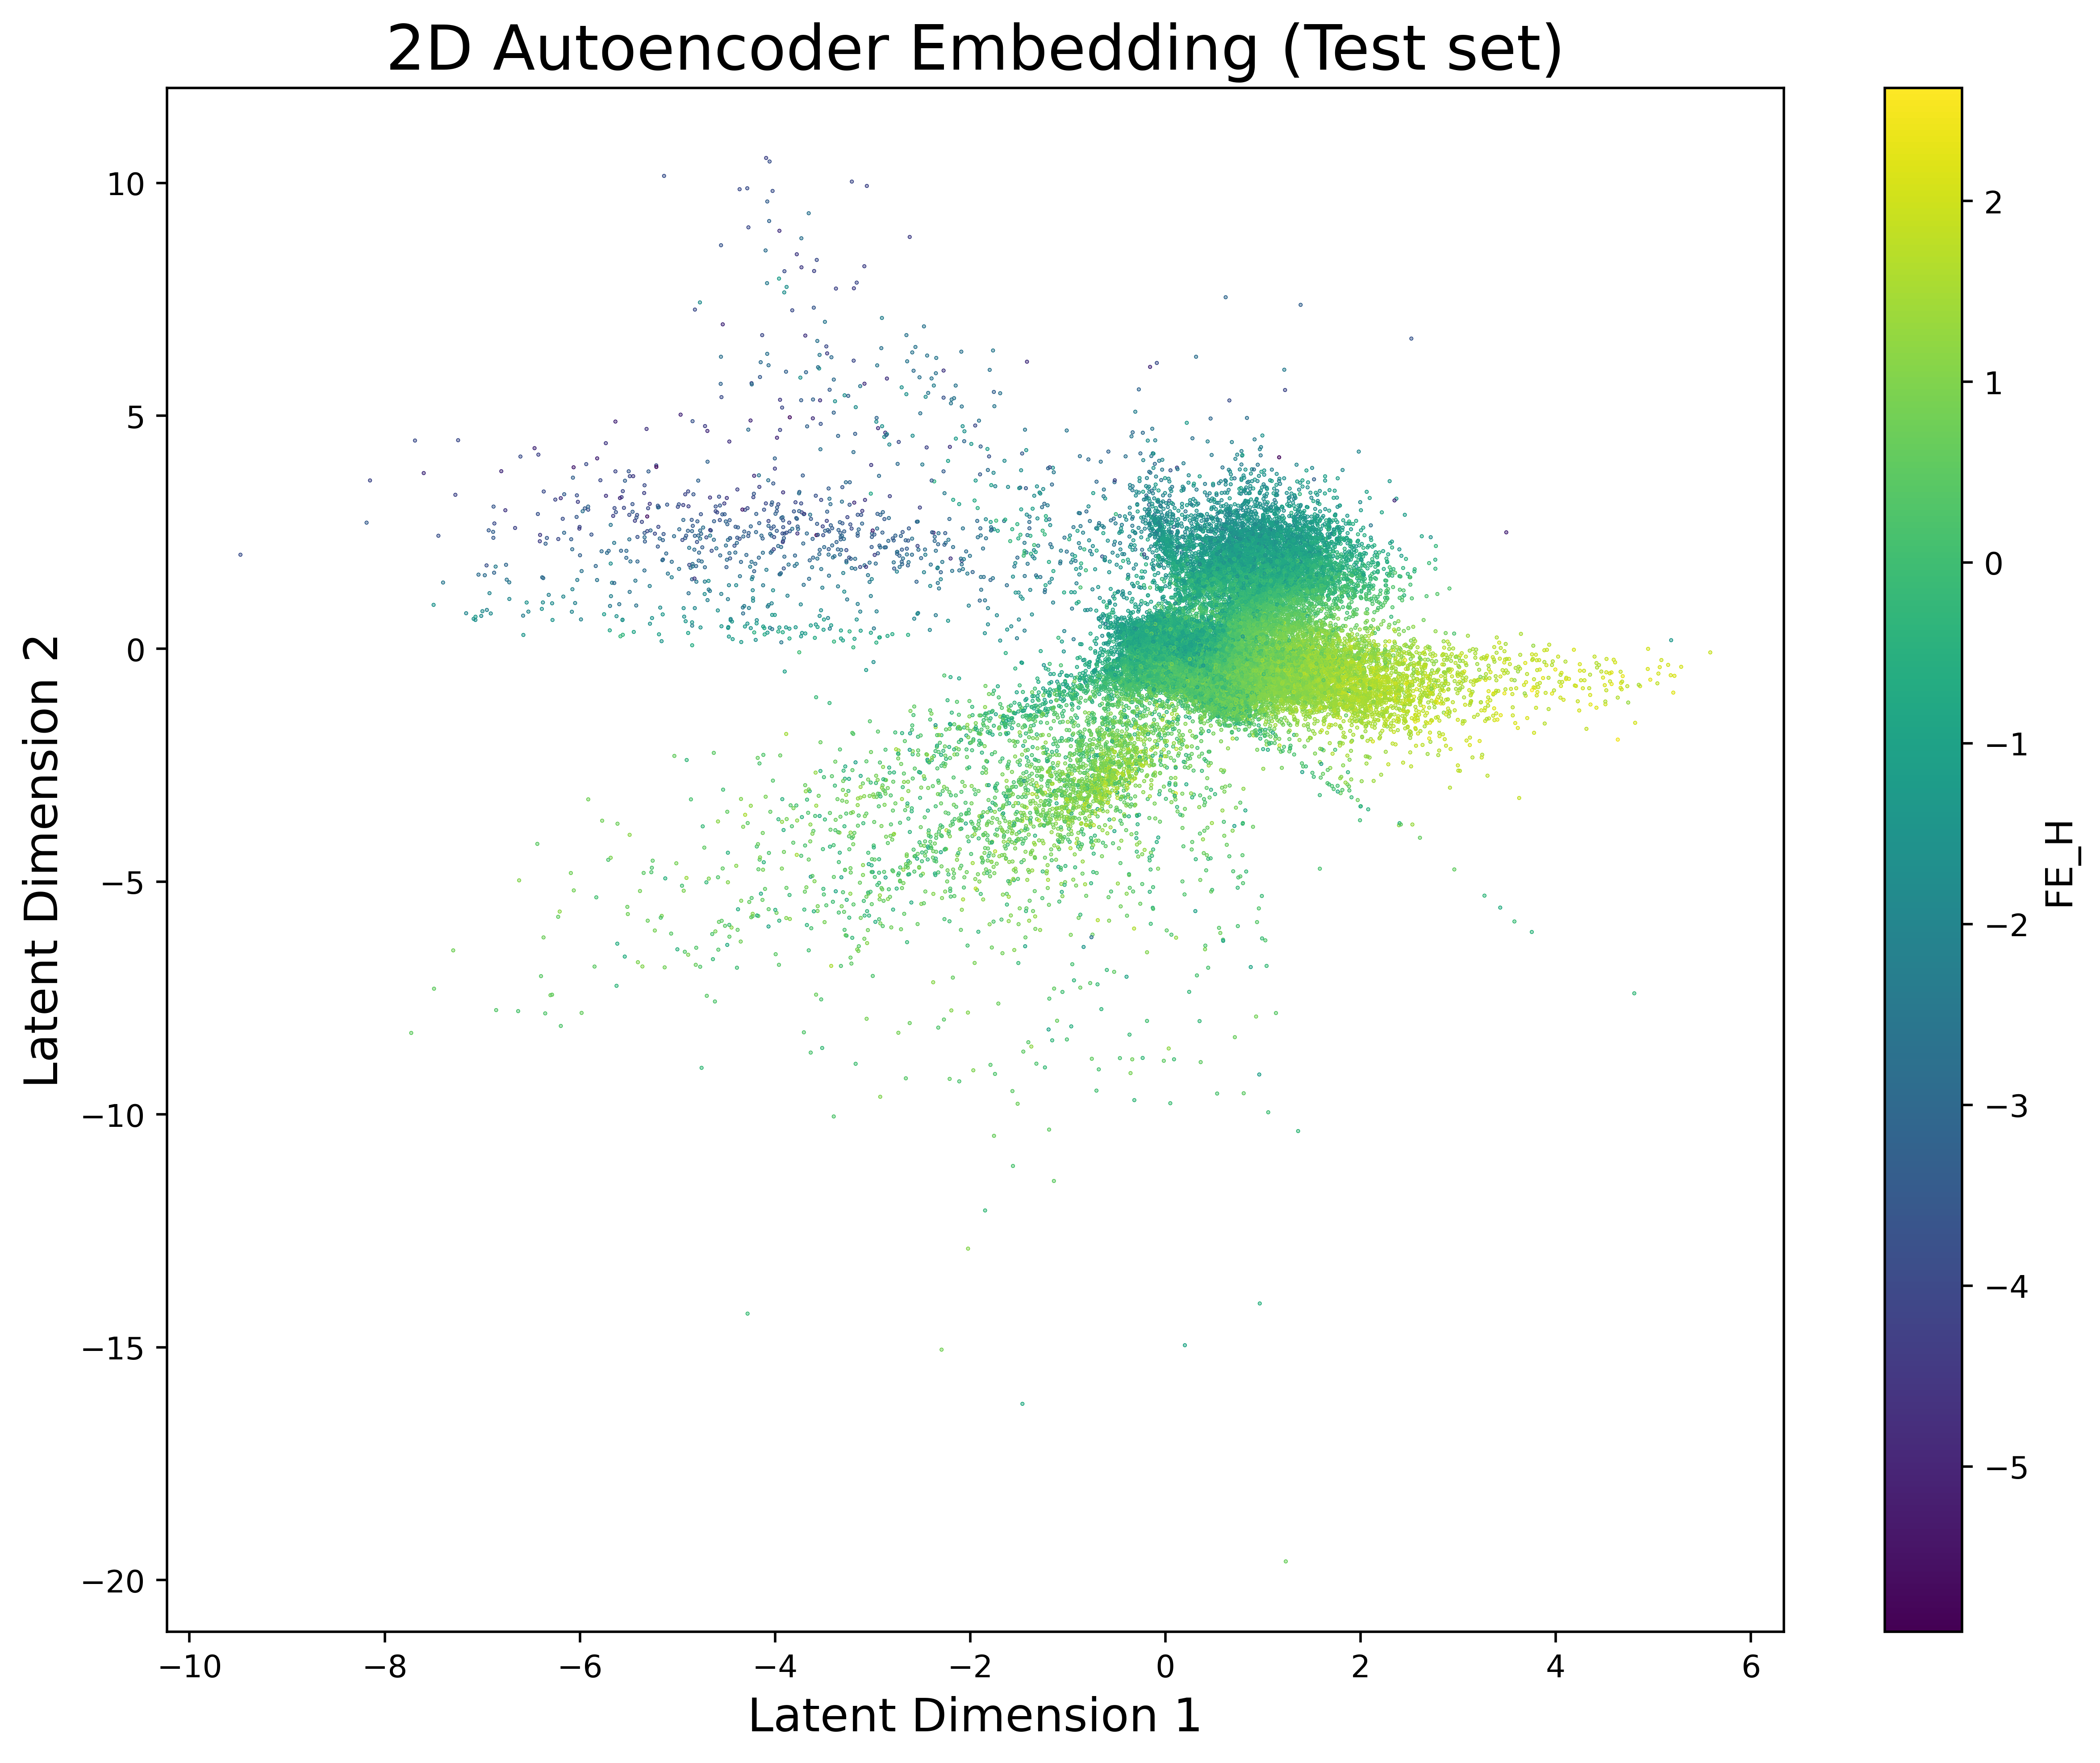

In [34]:
# Charger explicitement les embeddings depuis le CSV
data_to_plot = pd.read_csv("output_dataset/autoencoder_latent_space_2D.csv")


val_df_fe_h = val_df[['apogee_id', 'FE_H', 'TEFF']]
# get fe_h_values by merging with val_data
df_merged = pd.merge(data_to_plot, val_df_fe_h, on='apogee_id', how='inner')

# get latent_1 and latent_2 as numpy arrays
latent_1 = df_merged["latent_1"].values
latent_2 = df_merged["latent_2"].values
fe_h = df_merged["FE_H"].values

# Plot clair des embeddings avec FE_H comme couleur
fig = plt.figure(figsize=(10, 8), dpi=500)
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel('Latent Dimension 1', fontsize=15)
ax.set_ylabel('Latent Dimension 2', fontsize=15)
ax.set_title('2D Autoencoder Embedding (Test set)', fontsize=20)

scatter = ax.scatter(
    latent_1,
    latent_2,
    cmap='viridis',
    c=fe_h,
    s=0.1
)

cbar = plt.colorbar(scatter)
cbar.set_label('FE_H', fontsize=12)

plt.tight_layout()
plt.show()

Chosen star (Test set): apogee_id=2M01064163-0855466, row_index=1


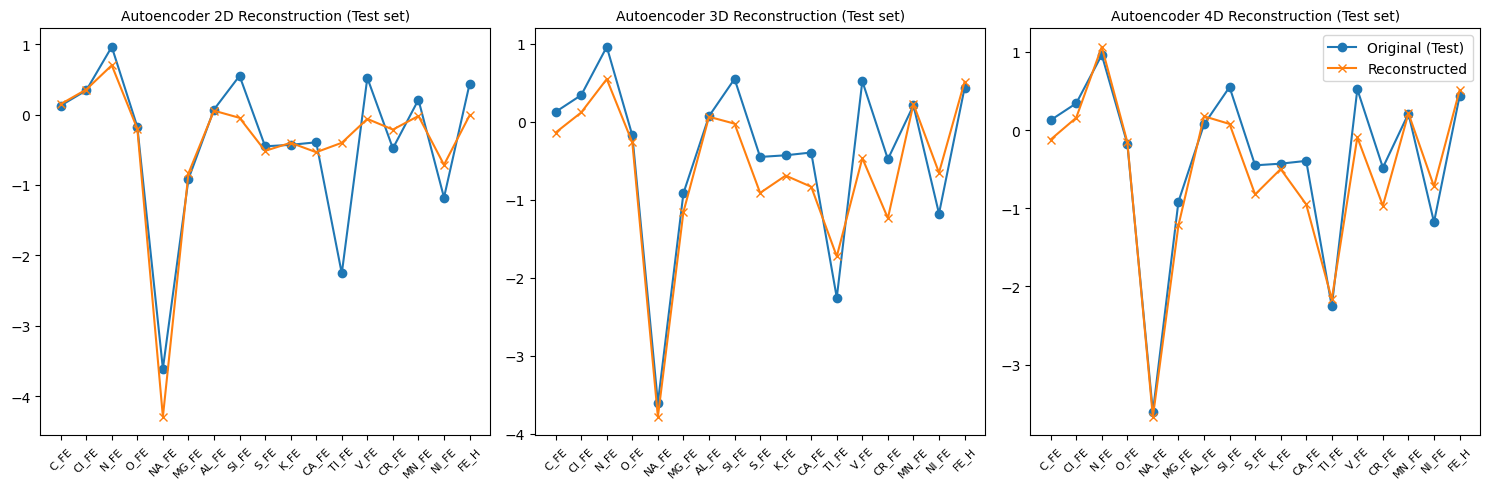

In [44]:
# Retrieve the list of numerical column names from the test DataFrame (excluding the 'apogee_id')
col_names = list(val_data.columns)  # numeric columns only

# Choose a specific star (apogee_id) to reconstruct
chosen_id = "2M01064163-0855466"
row_index = data_id_val[data_id_val == chosen_id].index
if len(row_index) == 0:
    raise ValueError(f"Unable to find apogee_id='{chosen_id}' in the TEST set.")
row_index = row_index[0]
print(f"Chosen star (Test set): apogee_id={chosen_id}, row_index={row_index}")

# Extract the original abundance data (as a NumPy array of float32)
original_abundance = val_data.iloc[row_index].values.astype(np.float32)

# Create a tensor for this single test sample (shape will be (1, 17))
x_star_tensor = val_tensor[row_index].unsqueeze(0).to(device)

# Define the list of latent dimensions we want to reconstruct with
latent_dims = [2, 3, 4]
reconstructions = {}  # will store the reconstructed abundances for each latent dimension

for d in latent_dims:
    # 1) Instantiate the same Autoencoder architecture as was used during training
    model = Autoencoder(
        input_dim=17, 
        latent_dim=d, 
        hidden_dim1=64, 
        hidden_dim2=96, 
        negative_slope=0.0056
    ).to(device)
    
    # compile the model so weight have the same name
    model = torch.compile(model, mode="reduce-overhead")

    # Construct the path to the saved weights for this dimension
    model_path = os.path.join(weight_folder, f"best_autoencoder_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Warning: No weights file found for {d}D: {model_path} ***")
        continue

    # 2) Load the full state_dict of the model
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)

    # Put the model in evaluation mode
    model.eval()
    
    # 4) Perform the forward pass to reconstruct our chosen test sample
    with torch.no_grad():
        x_recon = model(x_star_tensor).cpu().numpy().flatten()

    # Store the reconstructed abundances in the dictionary
    reconstructions[d] = x_recon

# --- Visualization ---
fig, axes = plt.subplots(1, len(latent_dims), figsize=(5 * len(latent_dims), 5), dpi=100)

# If there is only one latent dimension, wrap axes into a list
if len(latent_dims) == 1:
    axes = [axes]

for idx, d in enumerate(latent_dims):
    ax = axes[idx]

    # If no reconstruction was done for this dimension, display a placeholder
    if d not in reconstructions:
        ax.text(0.5, 0.5, f"{d}D\nNo model", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    # Retrieve the reconstructed data
    recon = reconstructions[d]
    x = np.arange(len(col_names))

    # Plot the original (test) abundances against the reconstructed values
    ax.plot(x, original_abundance, marker='o', label="Original (Test)")
    ax.plot(x, recon, marker='x', label="Reconstructed")

    ax.set_xticks(x)
    ax.set_xticklabels(col_names, rotation=45, fontsize=8)
    ax.set_title(f"Autoencoder {d}D Reconstruction (Test set)", fontsize=10)

    # Place the legend on the last subplot
    if idx == len(latent_dims) - 1:
        ax.legend()

plt.tight_layout()
plt.show()


Taille du jeu de TEST: (32282, 17), variance totale=16.8661
[2D] MSE=0.303830, Var_expl=0.981986
[3D] MSE=0.226009, Var_expl=0.986600
[4D] MSE=0.179892, Var_expl=0.989334


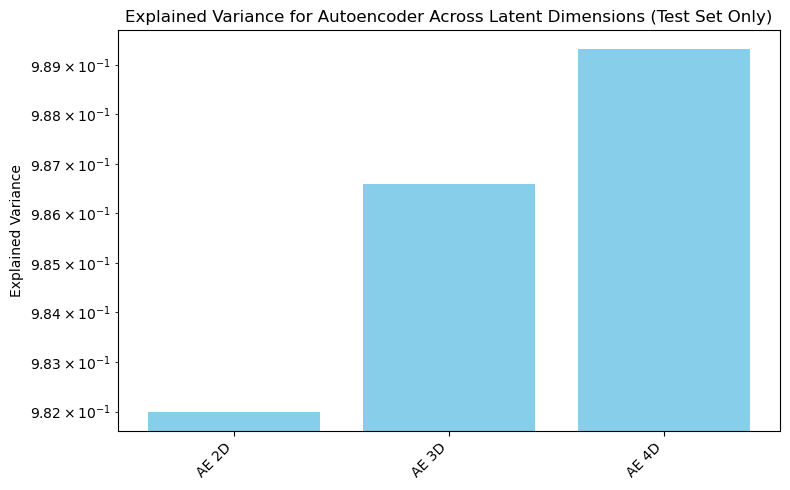

In [37]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------
# Récupération explicite du jeu TEST
# ---------------------------
val_X_tensor = val_tensor  # (N_test, 17)
val_X_np = val_X_tensor.cpu().numpy()

# Calcul explicite de la variance totale sur le TEST uniquement
cov_matrix = np.cov(val_X_np, rowvar=False)
total_variance = np.trace(cov_matrix)

print(f"Taille du jeu de TEST: {val_X_np.shape}, variance totale={total_variance:.4f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_folder = "output_weight"
latent_dims = [2, 3, 4]

explained_variances_ae = {}

val_X_tensor = val_X_tensor.to(device)

for d in latent_dims:
    model_path = os.path.join(weight_folder, f"best_autoencoder_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Pas de fichier de poids trouvé pour {d}D: {model_path} ***")
        continue

    # Charger le modèle Autoencoder exactement comme entraîné
    model = Autoencoder(input_dim=17, latent_dim=d, hidden_dim1=64, hidden_dim2=96, negative_slope=0.0056).to(device)
    model = torch.compile(model, mode="reduce-overhead")

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Reconstruction explicite du jeu TEST
    with torch.no_grad():
        x_recon_tensor = model(val_X_tensor)

    x_recon_np = x_recon_tensor.cpu().numpy()

    # Calcul explicite du MSE global sur TEST
    mse_global = np.mean((x_recon_np - val_X_np)**2)

    # Calcul de la variance expliquée sur TEST
    explained_variance = 1.0 - (mse_global / total_variance)
    explained_variances_ae[d] = explained_variance

    print(f"[{d}D] MSE={mse_global:.6f}, Var_expl={explained_variance:.6f}")

# ---------------------------
# Diagramme en barres clair de la variance expliquée sur TEST
# ---------------------------
labels = [f"AE {d}D" for d in latent_dims if d in explained_variances_ae]
ev_values = [explained_variances_ae[d] for d in latent_dims if d in explained_variances_ae]

plt.figure(figsize=(8, 5))
plt.bar(range(len(labels)), ev_values, color='skyblue')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.yscale("log")  # Échelle logarithmique pour une meilleure lisibilité
plt.title("Explained Variance for Autoencoder Across Latent Dimensions (Test Set Only)")
plt.tight_layout()
plt.show()
